<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


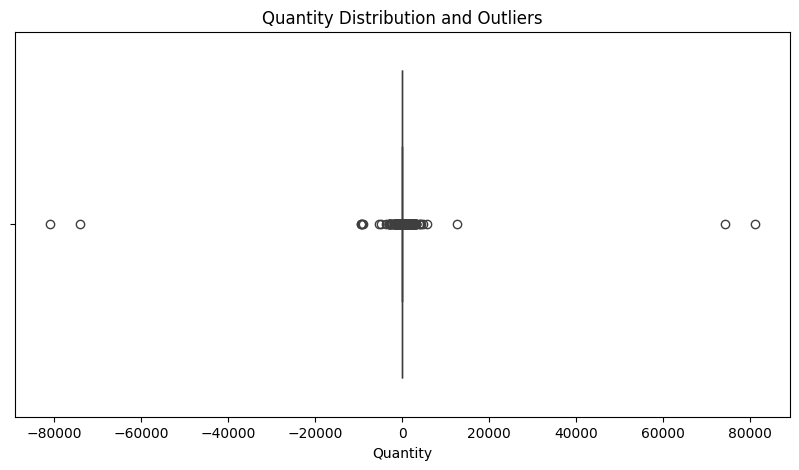

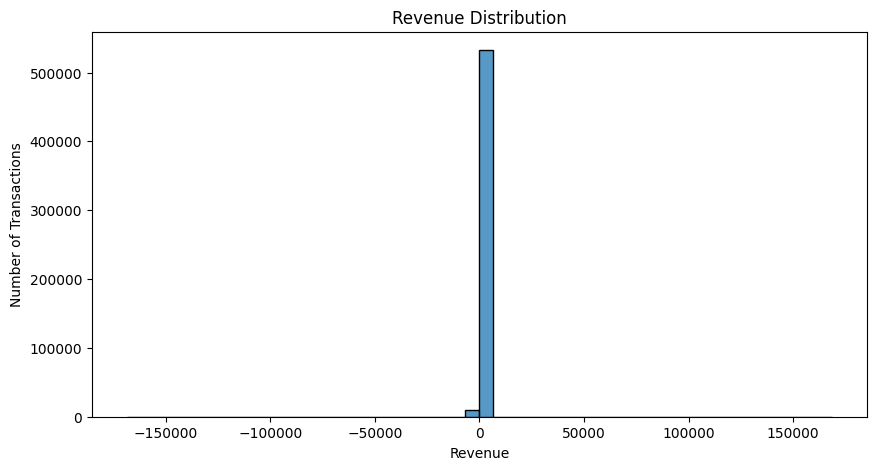

T-statistic: -23.030212729521747
P-value: 3.2109401580337504e-117
T-statistic: -23.030212729521747
P-value: 3.2109401580337504e-117


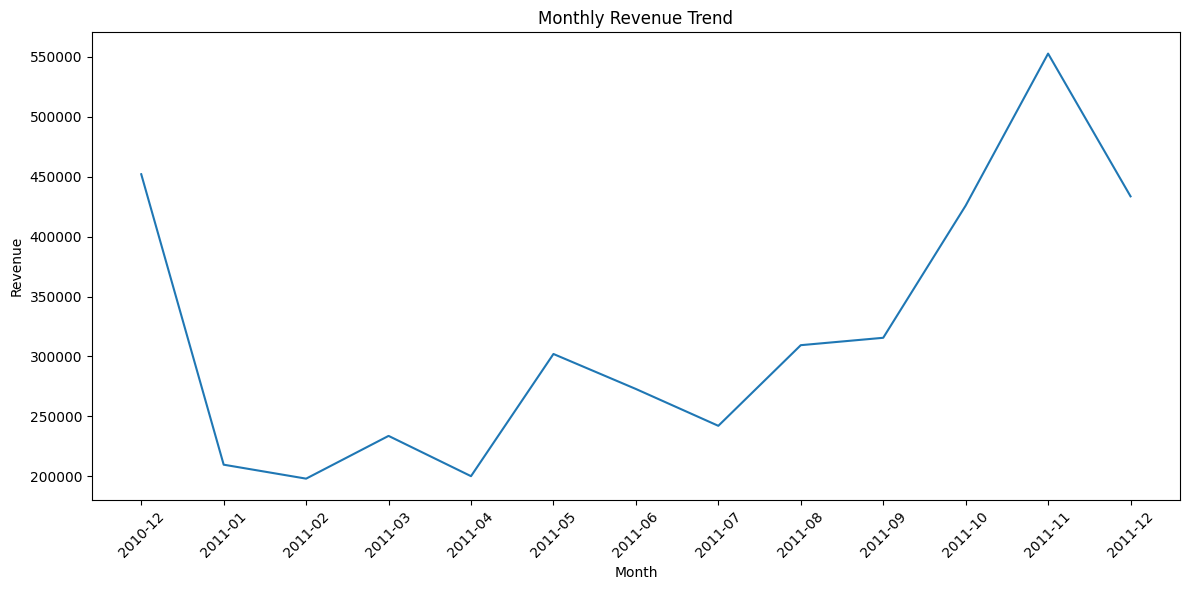

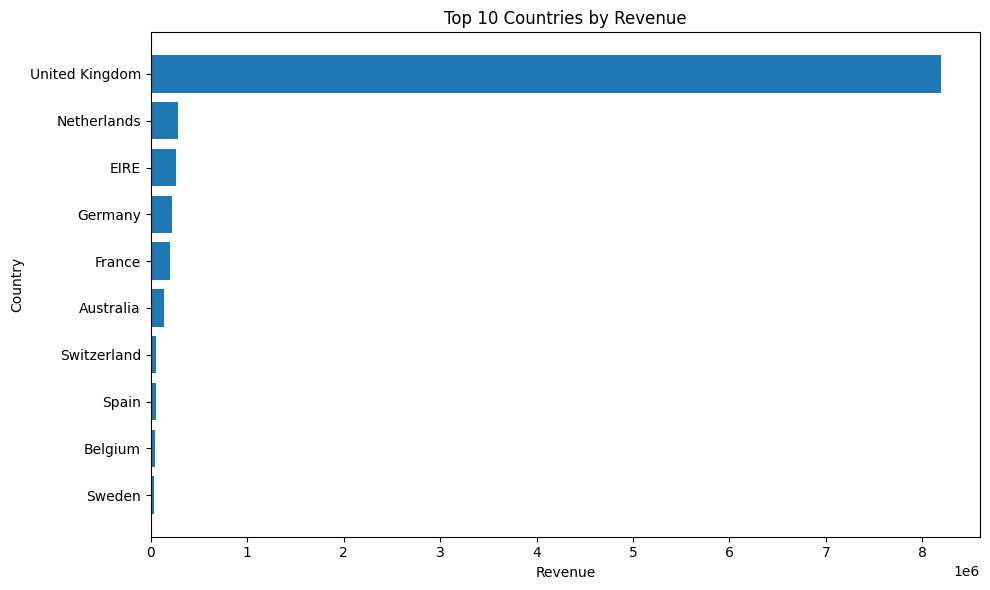

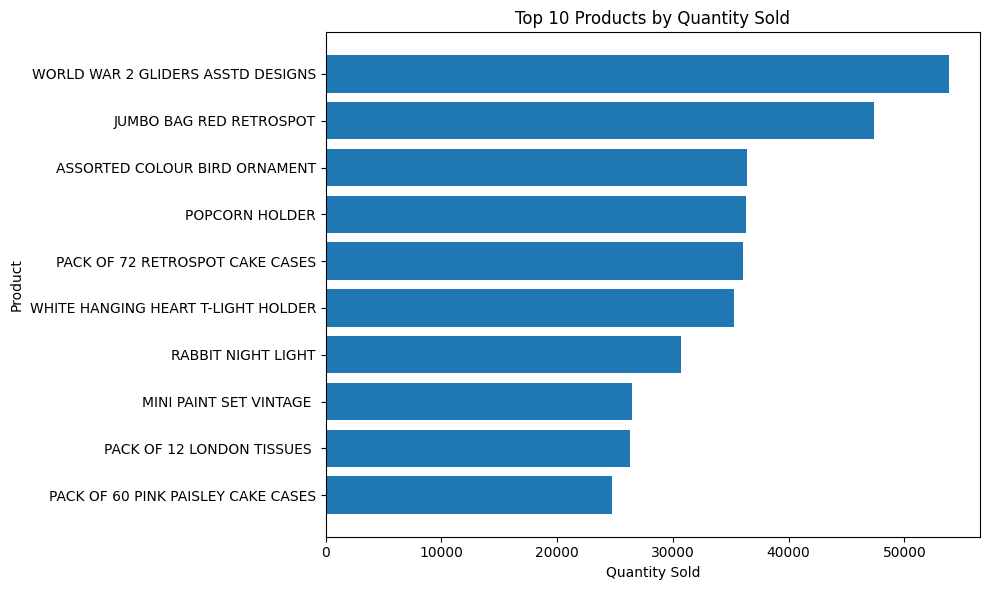

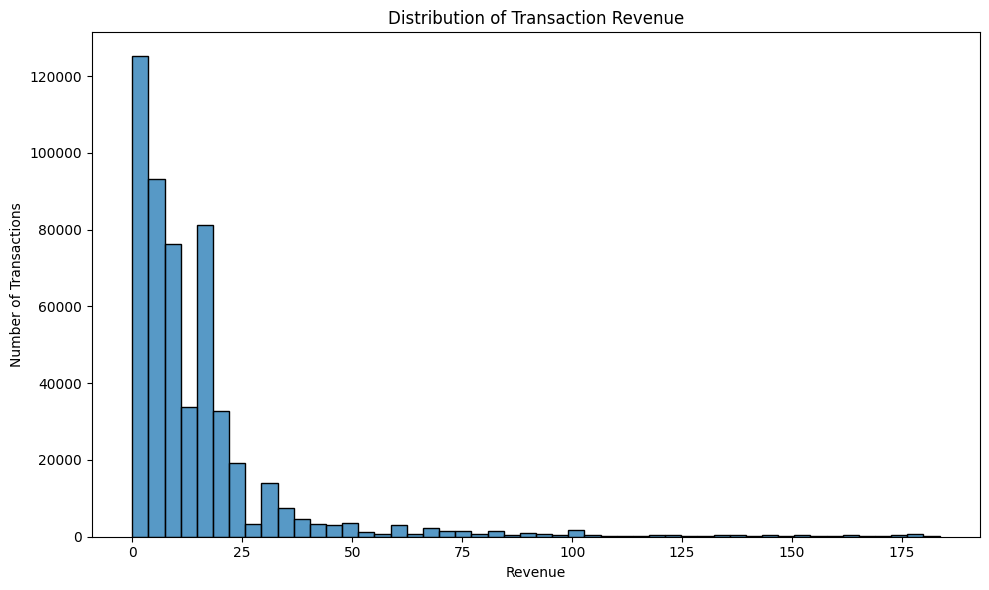

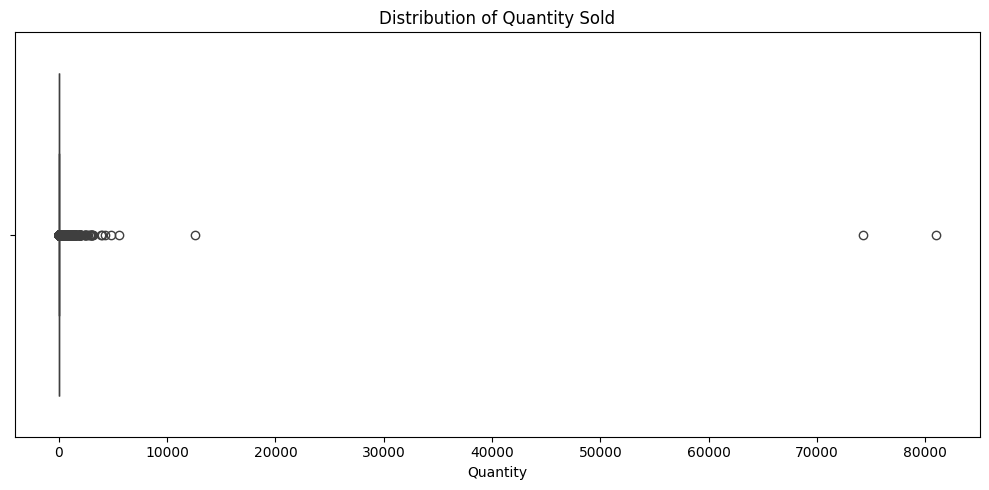

Total Revenue: 9747747.933999998
Number of unique products: 4223
Number of unique customers: 4372
Number of countries: 38
Highest revenue country: United Kingdom
Revenue: 8187806.364
Highest revenue product: DOTCOM POSTAGE
Revenue: 206245.48
Highest revenue month: 2011-11
Revenue: 552831.24
Total Revenue: 9747747.933999998
Unique Products: 4223
Unique Customers: 4372
Number of Countries: 38
Highest Revenue Country: United Kingdom
Highest Revenue Product: DOTCOM POSTAGE
Highest Revenue Month: 2011-11
Duplicate rows: 5269
Duplicates after cleaning: 0
Missing Description: 1454
Missing Description after cleaning: 0
Original rows: 541909
Cleaned transaction rows: 535186
Positive sales rows: 524877
Duplicate rows: 0
Duplicates after cleaning: 0
Missing Description: 0
Missing Description after cleaning: 0
Original rows: 541909
Cleaned transaction rows: 535186
Positive sales rows: 524877
Total Sales Revenue: 10642106.9
Average Transaction Revenue: 20.28
Median Transaction Revenue: 9.92


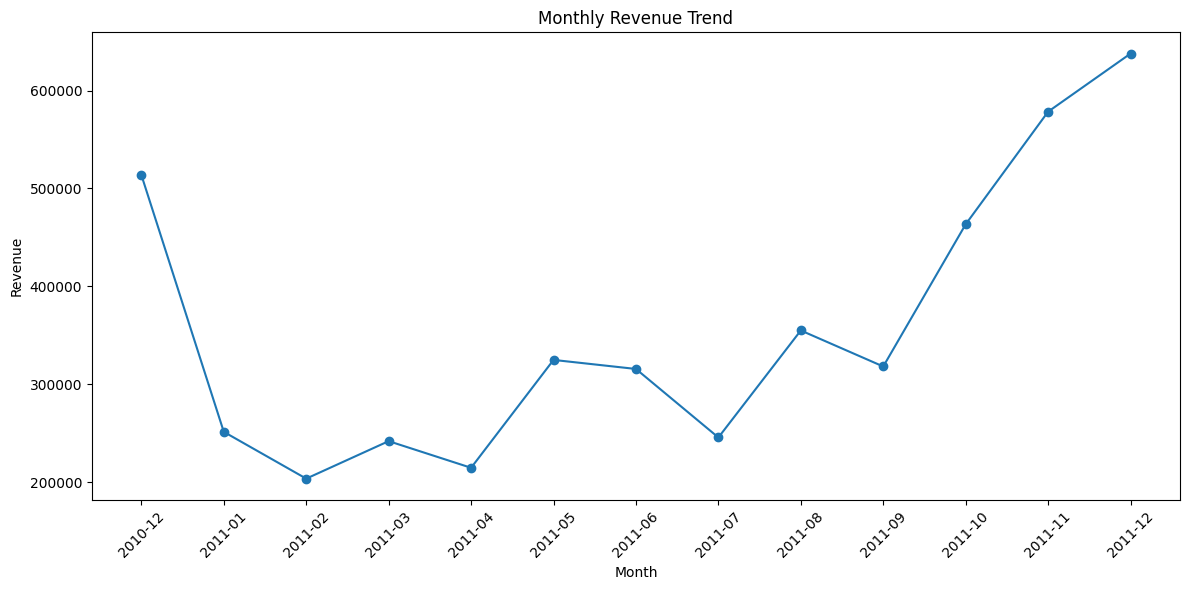

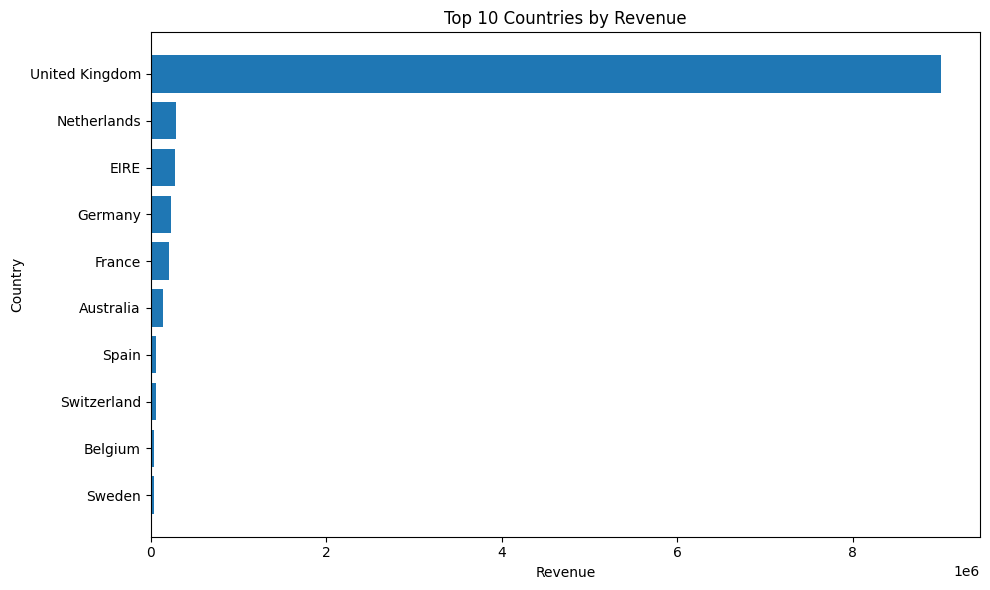

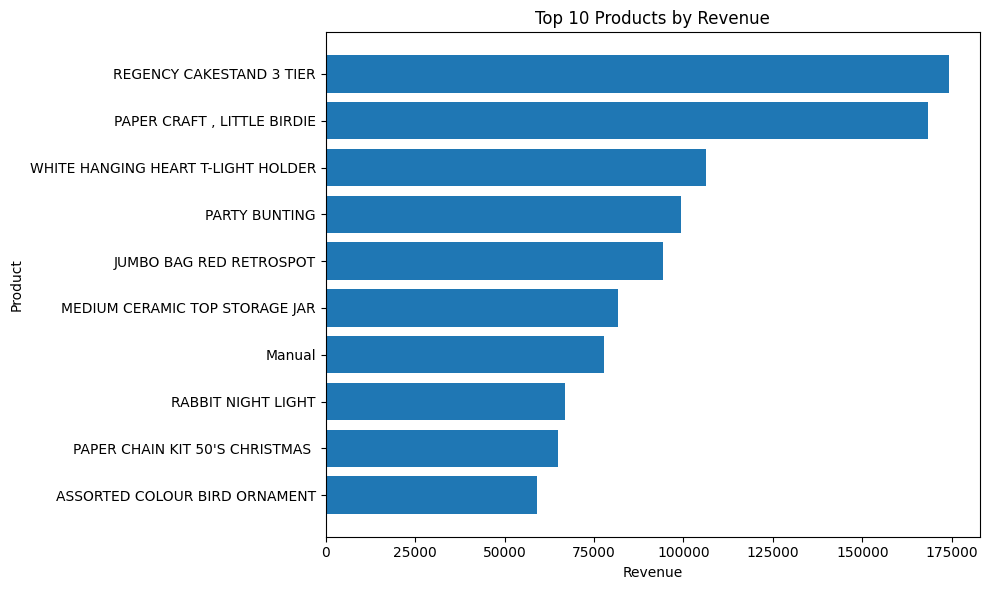

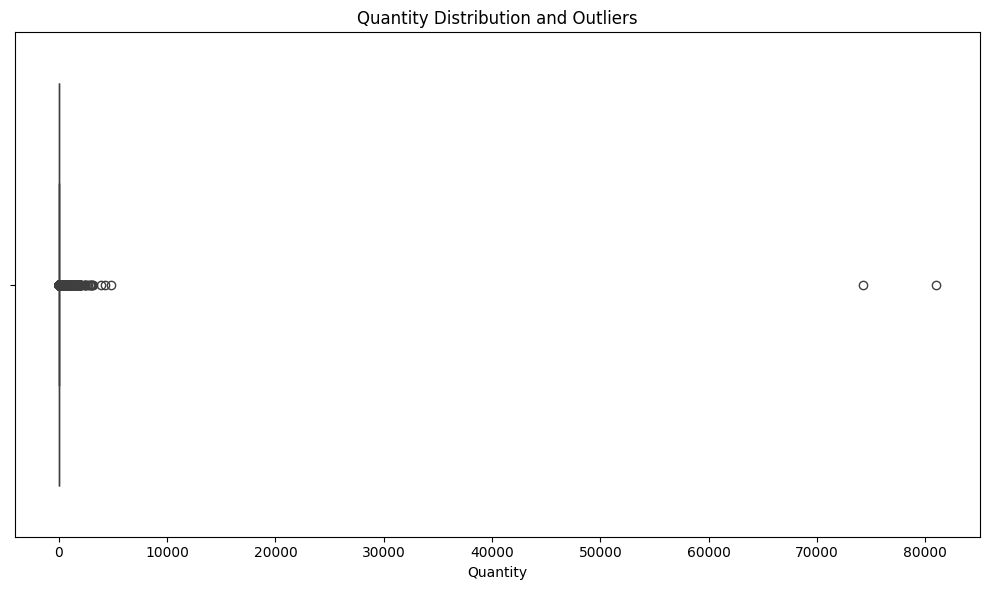

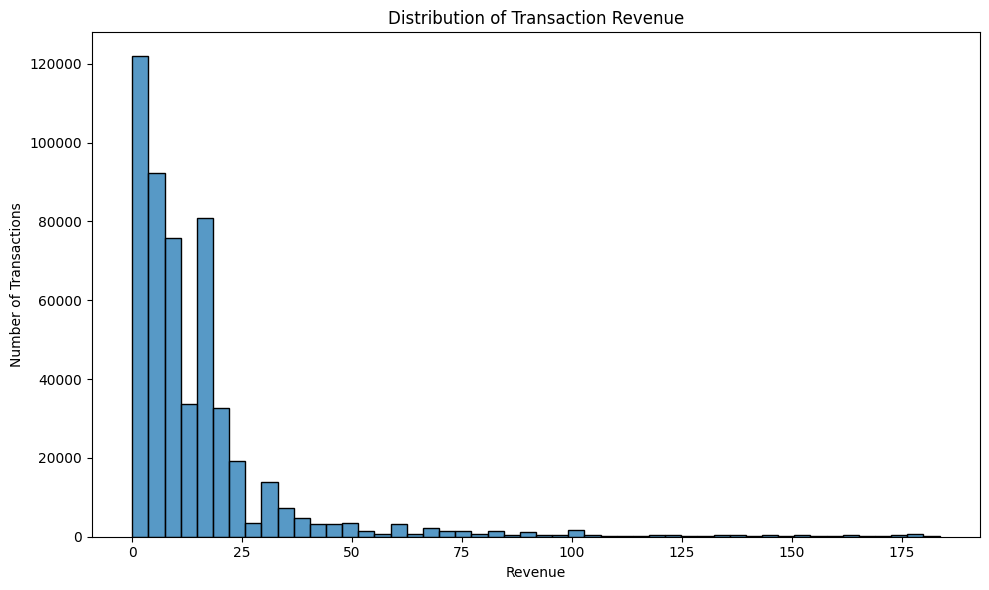

Total Sales Revenue: 10642106.9
Average Transaction Revenue: 20.28
Median Transaction Revenue: 9.92
Number of Products: 4016
Number of Countries: 38
Number of Customers: 4338


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Task 2.csv', encoding='latin1')
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()
df['Quantity'].describe()
(df['Quantity'] < 0).sum()
df['UnitPrice'].describe()
(df['UnitPrice'] <= 0).sum()
df['Quantity'].describe()
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
cancelled.head()
negative_quantity = df[df['Quantity'] < 0]
negative_quantity.shape
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'Revenue']].head()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['InvoiceDate'].isnull().sum()
df.describe()
df['Revenue'].sum()
df['Revenue'].mean()
df['Revenue'].median()
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue.head(10)
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
product_revenue.head(10)
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
product_revenue.head(10)
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue
monthly_revenue.sort_values(ascending=False).head(10)
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)
country_orders.head(10)
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Quantity'])
plt.title('Quantity Distribution and Outliers')
plt.show()
plt.figure(figsize=(10,5))
sns.histplot(df['Revenue'], bins=50)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Transactions')
plt.show()
uk_revenue = df[df['Country'] == 'United Kingdom']['Revenue'].dropna()
other_revenue = df[df['Country'] != 'United Kingdom']['Revenue'].dropna()
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(uk_revenue, other_revenue, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)
uk_revenue = df[df['Country'] == 'United Kingdom']['Revenue'].dropna()
other_revenue = df[df['Country'] != 'United Kingdom']['Revenue'].dropna()
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(uk_revenue, other_revenue, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

plt.figure(figsize=(12, 6))

plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
top_countries = country_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_countries.index, top_countries.values)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

top_products_quantity = top_products.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_products_quantity.index, top_products_quantity.values)

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

positive_revenue = df[df['Revenue'] > 0]['Revenue']

plt.figure(figsize=(10, 6))

sns.histplot(positive_revenue[positive_revenue < positive_revenue.quantile(0.99)], bins=50)

plt.title('Distribution of Transaction Revenue')
plt.xlabel('Revenue')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

positive_quantity = df[df['Quantity'] > 0]['Quantity']

plt.figure(figsize=(10, 5))

sns.boxplot(x=positive_quantity)

plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')

plt.tight_layout()
plt.show()

total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

unique_products = df['Description'].nunique()
print("Number of unique products:", unique_products)
unique_customers = df['CustomerID'].nunique()
print("Number of unique customers:", unique_customers)
unique_countries = df['Country'].nunique()
print("Number of countries:", unique_countries)

highest_country = country_revenue.idxmax()
highest_country_revenue = country_revenue.max()

print("Highest revenue country:", highest_country)
print("Revenue:", highest_country_revenue)

highest_product = product_revenue.idxmax()
highest_product_revenue = product_revenue.max()

print("Highest revenue product:", highest_product)
print("Revenue:", highest_product_revenue)

highest_month = monthly_revenue.idxmax()
highest_month_revenue = monthly_revenue.max()

print("Highest revenue month:", highest_month)
print("Revenue:", highest_month_revenue)

summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Unique Products',
        'Unique Customers',
        'Number of Countries',
        'Highest Revenue Country',
        'Highest Revenue Product',
        'Highest Revenue Month'
    ],
    'Value': [
        total_revenue,
        unique_products,
        unique_customers,
        unique_countries,
        highest_country,
        highest_product,
        str(highest_month)
    ]
})

summary
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

unique_products = df['Description'].nunique()
print("Unique Products:", unique_products)

unique_customers = df['CustomerID'].nunique()
print("Unique Customers:", unique_customers)

unique_countries = df['Country'].nunique()
print("Number of Countries:", unique_countries)

highest_country = country_revenue.idxmax()
print("Highest Revenue Country:", highest_country)

highest_product = product_revenue.idxmax()
print("Highest Revenue Product:", highest_product)

highest_month = monthly_revenue.idxmax()
print("Highest Revenue Month:", highest_month)

df[df['Description'].str.contains('POSTAGE|CARRIAGE|CHARGE|BANK CHARGES',
                                   case=False, na=False)]['Description'].value_counts().head(20)

service_items = df[df['Description'].str.contains(
    'POSTAGE|CARRIAGE|CHARGE|BANK CHARGES',
    case=False,
    na=False
)]

service_items[['Description', 'Quantity', 'UnitPrice', 'Revenue']].head(20)

duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())

print("Missing Description:", df['Description'].isnull().sum())
df = df.dropna(subset=['Description'])
print("Missing Description after cleaning:", df['Description'].isnull().sum())

customer_data = df.dropna(subset=['CustomerID'])
sales_df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
print("Original rows:", 541909)
print("Cleaned transaction rows:", len(df))
print("Positive sales rows:", len(sales_df))

duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())

print("Missing Description:", df['Description'].isnull().sum())

df = df.dropna(subset=['Description'])

print("Missing Description after cleaning:", df['Description'].isnull().sum())

sales_df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['UnitPrice']

print("Original rows:", 541909)
print("Cleaned transaction rows:", len(df))
print("Positive sales rows:", len(sales_df))

total_sales = sales_df['Revenue'].sum()
print("Total Sales Revenue:", round(total_sales, 2))
average_sales = sales_df['Revenue'].mean()
median_sales = sales_df['Revenue'].median()

print("Average Transaction Revenue:", round(average_sales, 2))
print("Median Transaction Revenue:", round(median_sales, 2))

product_sales_df = sales_df[
    ~sales_df['Description'].str.contains(
        'POSTAGE|CARRIAGE|CHARGE|BANK CHARGES',
        case=False,
        na=False
    )
].copy()

top_10_products = (
    product_sales_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products
top_10_revenue_products = (
    product_sales_df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_revenue_products
clean_country_revenue = (
    sales_df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

clean_country_revenue.head(10)

sales_df['Month'] = sales_df['InvoiceDate'].dt.to_period('M')

clean_monthly_revenue = (
    sales_df.groupby('Month')['Revenue']
    .sum()
)
clean_monthly_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

plt.plot(
    clean_monthly_revenue.index.astype(str),
    clean_monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

top_10_countries = clean_country_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries.index,
    top_10_countries.values
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

top_10_product_revenue = top_10_revenue_products.sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_product_revenue.index,
    top_10_product_revenue.values
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(x=sales_df['Quantity'])

plt.title('Quantity Distribution and Outliers')
plt.xlabel('Quantity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

revenue_for_plot = sales_df[
    sales_df['Revenue'] < sales_df['Revenue'].quantile(0.99)
]['Revenue']

sns.histplot(revenue_for_plot, bins=50)

plt.title('Distribution of Transaction Revenue')
plt.xlabel('Revenue')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

print("Total Sales Revenue:", round(sales_df['Revenue'].sum(), 2))
print("Average Transaction Revenue:", round(sales_df['Revenue'].mean(), 2))
print("Median Transaction Revenue:", round(sales_df['Revenue'].median(), 2))

print("Number of Products:", product_sales_df['Description'].nunique())
print("Number of Countries:", sales_df['Country'].nunique())
print("Number of Customers:", sales_df['CustomerID'].nunique())

# Exploratory Data Analysis of Online Retail Transactions

## Internship Task 2

**Project:** Exploratory Data Analysis (EDA)  
**Dataset:** Online Retail Transaction Dataset  
**Tools:** Python, Pandas, NumPy, Matplotlib and Seaborn

## 1. Introduction

Exploratory Data Analysis (EDA) is an important process in data analytics used to understand the structure, quality, patterns and relationships present in a dataset. It helps identify missing values, duplicate records, unusual observations and trends before further analysis.

In this project, an Online Retail transaction dataset is analyzed to understand sales performance, product demand, customer information, geographical distribution and revenue trends. The analysis also includes data cleaning, descriptive statistics, visualization and hypothesis testing to generate meaningful business insights.

## 2. Objective

The main objectives of this analysis are:

- To understand the structure and characteristics of the retail dataset.
- To identify and handle data-quality issues.
- To analyze sales and revenue patterns.
- To identify high-performing products and countries.
- To examine monthly revenue trends.
- To identify unusual values and potential outliers.
- To perform statistical hypothesis testing.
- To generate meaningful business insights using data visualization.

## 3. Dataset Description

The dataset contains online retail transaction records with information about invoices, products, quantities, transaction dates, prices, customers and countries.

The original dataset contains 541,909 transaction records and 8 variables.

### Variables

| Variable | Description |
|---|---|
| InvoiceNo | Invoice or transaction number |
| StockCode | Product identification code |
| Description | Product description |
| Quantity | Number of items purchased |
| InvoiceDate | Date and time of transaction |
| UnitPrice | Price per item |
| CustomerID | Customer identification number |
| Country | Customer's country |

## 4. Business Questions

The analysis aims to answer the following questions:

1. What is the overall sales revenue?
2. Which countries generate the highest revenue?
3. Which products have the highest sales quantity?
4. Which products generate the highest revenue?
5. Which month has the highest revenue?
6. Are there missing values in the dataset?
7. Are there duplicate records?
8. Are there unusual quantities or prices?
9. What patterns and trends can be identified?
10. Is there a statistically significant difference in transaction revenue between the United Kingdom and other countries?

## 5. Data Understanding

Before performing data cleaning and analysis, the dataset was examined to understand its structure, columns, data types and basic characteristics.

df.head()

The dataset contains 541,909 transaction records and 8 variables. The variables provide information about invoices, products, quantities, transaction dates, prices, customers and countries.

## 6. Data Quality Analysis

The dataset was checked for missing values, duplicate records and unusual values to identify potential data-quality issues.

### Missing Values

[Your existing missing-value output]

### Duplicate Records

[Your existing duplicate check/output]

### Unusual Values

Negative quantities were identified and investigated as possible returns or cancelled transactions. Unit prices were also checked for zero or negative values.

## 7. Data Cleaning

After identifying the data-quality issues, the dataset was cleaned to improve the accuracy and reliability of the analysis. Duplicate records were removed, rows with missing product descriptions were excluded, and valid sales transactions were separated from returns and transactions with invalid prices.

### 7.1 Handling Duplicate Records

Duplicate transaction records were removed to prevent the same transaction from being counted more than once.

### 7.2 Handling Missing Values

Rows with missing product descriptions were removed because the product description is required for product-level analysis. Missing CustomerID values were retained because these transactions can still provide useful information for overall sales and revenue analysis.

### 7.3 Handling Invalid Transactions

Transactions with negative quantities were treated as returns or cancellations and were excluded from the positive-sales analysis. Transactions with zero or negative unit prices were also excluded from the valid-sales analysis.

## 8. Feature Engineering

Feature engineering is the process of creating new variables from existing data to make the analysis more meaningful.

For this dataset, a new Revenue variable was created by multiplying Quantity by UnitPrice. This helps measure the total value of each transaction.

A Month variable was also created from InvoiceDate to analyze revenue trends over different months.

### Revenue

Revenue = Quantity × UnitPrice

### Month

The transaction date was converted into a monthly period so that monthly revenue patterns could be analyzed.

## 9. Descriptive Statistics

Descriptive statistics were used to summarize the main characteristics of the retail transaction data. Measures such as count, mean, standard deviation, minimum, maximum and quartiles were examined for numerical variables such as Quantity, UnitPrice and Revenue.

These statistics help in understanding the typical transaction size, variation in prices and quantities, and the overall distribution of sales values.

The analysis showed that the retail dataset contains substantial variation in transaction quantities, unit prices and revenue. This variation is useful for identifying customer purchasing patterns and potential outliers in later stages of the analysis.

## 10. Business Analysis

The cleaned retail transaction data was analyzed to understand overall sales performance, country-wise revenue, product demand and customer-related patterns.

### 10.1 Overall Revenue

The total revenue generated in the initial analysis was approximately £9.75 million. Revenue was calculated using the Quantity and UnitPrice of each transaction.

### 10.2 Country-wise Revenue

The United Kingdom generated the highest revenue among all countries in the dataset. This indicates that the UK was the primary market for the online retail business.

### 10.3 Product Analysis

Products were analyzed based on both sales quantity and revenue. This helps identify products that are highly demanded as well as products that contribute significantly to revenue.

Service-related entries such as postage and charges were treated separately from actual merchandise when evaluating product performance.

### 10.4 Customer Analysis

Customer-level revenue was examined to understand the contribution of individual customers and identify high-value customers.

## 11. Time Trend Analysis

The monthly revenue trend was analyzed to understand how sales performance changed over time. The transaction date was converted into monthly periods and total revenue was calculated for each month.

The analysis showed that revenue varied across different months. November 2011 recorded the highest monthly revenue in the initial analysis, with approximately £552,831 in revenue.

Analyzing monthly trends helps identify periods of high and low sales activity and can support future sales planning and business decision-making.

## 12. Outlier Analysis

Outlier analysis was performed to identify unusually high or low values in the transaction data. The Quantity and Revenue variables were examined because extreme values can strongly affect the results of sales analysis.

The analysis showed that some transactions contain unusually large quantities or revenue values compared with typical transactions. These values may represent bulk purchases, special orders or other unusual transactions rather than errors.

Therefore, extreme values were not automatically removed. They were examined carefully so that genuine business transactions were not incorrectly deleted from the dataset.

## 13. Hypothesis Testing

A hypothesis test was performed to determine whether there is a significant difference in average transaction revenue between the United Kingdom and other countries.

### Null Hypothesis (H₀)

There is no significant difference in average transaction revenue between the United Kingdom and other countries.

### Alternative Hypothesis (H₁)

There is a significant difference in average transaction revenue between the United Kingdom and other countries.

An independent two-sample t-test was used to compare the average transaction revenue of the two groups.

The p-value obtained from the test was used to make the final decision. If the p-value is less than 0.05, the null hypothesis is rejected. If the p-value is greater than or equal to 0.05, the null hypothesis is not rejected.

This analysis helps determine whether the observed difference in transaction revenue between the UK and other countries is statistically significant.

## 14. Data Visualization

Data visualization was used to present the results of the analysis in a clear and easy-to-understand format. Charts help identify trends, comparisons and patterns that may not be easily visible from numerical data alone.

The analysis includes visualizations for monthly revenue trends, top countries by revenue, top products by revenue, quantity distribution and transaction revenue distribution.

These visualizations provide a better understanding of sales performance and support the business insights obtained from the exploratory analysis.

## 15. Key Findings

The exploratory analysis of the Online Retail dataset produced the following key findings:

- The dataset contains 541,909 transaction records and 8 variables.
- The total revenue in the initial analysis was approximately £9.75 million.
- The United Kingdom was the highest revenue-generating country.
- The dataset contains a large variety of products and customers.
- November 2011 recorded the highest monthly revenue in the initial analysis, at approximately £552,831.
- Missing values were mainly found in the Description and CustomerID columns.
- Negative quantities were identified and investigated as possible returns or cancelled transactions.
- Some transactions contained unusually high quantities or revenue values and were examined as potential outliers.
- Product performance was analyzed separately from service-related entries such as postage and charges.
- Hypothesis testing was performed to examine whether transaction revenue differed significantly between the UK and other countries.

## 16. Conclusion

The Exploratory Data Analysis of the Online Retail dataset provided useful insights into the company's sales performance, products, customers, countries and revenue trends.

The analysis included data understanding, data-quality checking, data cleaning, feature engineering, descriptive statistics, business analysis, time-trend analysis, outlier analysis, hypothesis testing and data visualization.

The findings show that the United Kingdom is the major revenue-generating market and that sales performance varies across products and months. The analysis also identified missing values, duplicate records, returns and unusual transactions that needed to be considered during the analysis.

Overall, the EDA process helped transform the raw transaction data into meaningful business insights that can support better sales analysis and decision-making.

